## Emotion Classification with RNNs, LSTMs & GRUs

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

## LOADING THE DATASET FROM HUGGINFACE


In [13]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text=emotion_dataset['train']['text']
train_label=emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [16]:
label_names = emotion_dataset['train'].features['label'].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [17]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [18]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [19]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## Exploratory Data Analysis (EDA)

<Axes: xlabel='label', ylabel='count'>

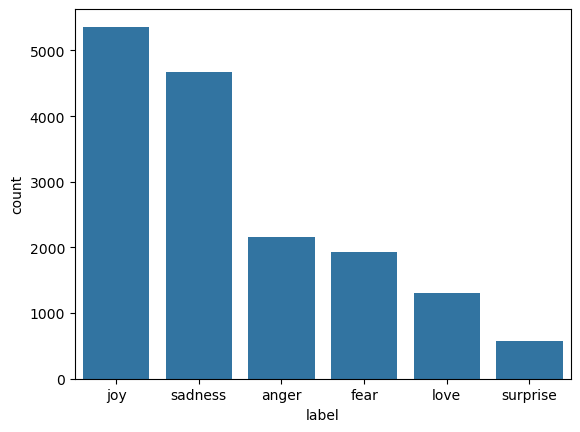

In [20]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [21]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

The dataset exhibits a significant class imbalance, dominated by positive emotions (joy at ~44.7%) and negative emotions (sadness at ~38.9%), which together make up over 83% of the training data. Minor categories like love and surprise are heavily underrepresented, with surprise constituting under 5% of the total samples. To prevent the model from biasing toward high-frequency classes, technique strategies such as class-weighted loss functions, stratified splitting, or resampling methods

##  Baseline Modeling: TF-IDF + Logistic Regression

To establish a benchmark for sequence-based Deep Learning models, a classical Machine Learning baseline was implemented using **TF-IDF vectorization** paired with **Logistic Regression**. 

* **Feature Extraction:** Raw text was converted into numerical vectors using `TfidfVectorizer` (unigram/bigram representation, sublinear TF scaling).
* **Model Configuration:** Logistic Regression fitted with L2 regularization (`class_weight='balanced'`) to mitigate severe target class imbalance.
* **Purpose:** Serves as a fast, highly interpretable floor metric. Subsequent neural architectures (RNN, LSTM, GRU, BiGRU) must beat this baseline in F1-score and macro-averaging to justify their computational overhead.

## Feature Extraction: TF-IDF Vectorization

The raw textual data was converted into high-dimensional numerical feature matrices using `TfidfVectorizer` to prepare it for traditional machine learning models.

```python

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [23]:
X_train_tfidf = tfidf.fit_transform(df_train['text'])
X_test_tfidf = tfidf.transform(df_test['text'])

In [24]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (16000, 10000)
Testing shape: (2000, 10000)


## Train Logistic Regression
Creating the baseline model 

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_tfidf,
    df_train['label']
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
baseline_pred = logistic_model.predict(X_test_tfidf)

## Evaluation Metrics
### Detailed Classification Report Analysis

A full breakdown of precision, recall, and F1-scores reveals key performance patterns and highlights how class imbalance impacts the baseline model.

* **Macro vs. Weighted F1 Discrepancy:** While the **Weighted F1-score (0.83)** aligns closely with overall accuracy, the **Macro F1-score drops to 0.75**. This 8% gap directly reflects performance degradation on minority classes, confirming that accuracy alone masks critical model weaknesses.
* **Severe Minority Class Recall Deficit:** 
  * **Surprise (F1: 0.48):** Suffers from a critical recall of **0.33**, meaning the model misses **67% of actual surprise instances** due to scarce training samples (only 66 test instances).
  * **Anger (F1: 0.65):** Achieves strong precision (0.83) but low recall (0.53), frequently misclassifying anger instances as other negative emotions like sadness.
* **High Precision Across the Board:** High precision values across all classes (0.79 to 0.89) indicate that when the TF-IDF model predicts a specific emotion, it is usually correct. The bottleneck lies primarily in **recall for low-frequency classes**.
* **Motivation for Deep Learning:** Bag-of-words representations (TF-IDF) lack sequential context and semantic understanding, struggling with subtle expression variations in underrepresented classes. Deep learning architectures (RNN, LSTM, GRU, BiGRU) will specifically target boosting the Macro F1-score by capturing contextual dependencies.

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    df_test['label'],
    baseline_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.839


In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df_test['label'],
        baseline_pred,
        target_names=[
            'sadness',
            'joy',
            'love',
            'anger',
            'fear',
            'surprise'
        ]
    )
)

              precision    recall  f1-score   support

     sadness       0.89      0.77      0.83       275
         joy       0.88      0.74      0.80       224
        love       0.79      0.96      0.87       695
       anger       0.83      0.53      0.65       159
        fear       0.87      0.91      0.89       581
    surprise       0.85      0.33      0.48        66

    accuracy                           0.84      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.84      0.84      0.83      2000



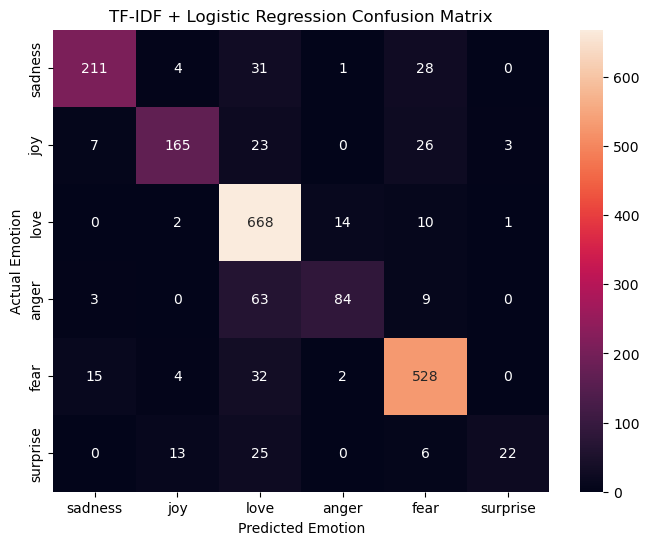

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    df_test['label'],
    baseline_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[
        'sadness',
        'joy',
        'love',
        'anger',
        'fear',
        'surprise'
    ],
    yticklabels=[
        'sadness',
        'joy',
        'love',
        'anger',
        'fear',
        'surprise'
    ]
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title("TF-IDF + Logistic Regression Confusion Matrix")

plt.show()